Train epoch 1/3: 100%|██████████| 235/235 [00:18<00:00, 12.67it/s, loss=11.3937]


Epoch 1 mean loss: 11.3937


Train epoch 2/3: 100%|██████████| 235/235 [00:18<00:00, 12.42it/s, loss=7.1310]


Epoch 2 mean loss: 7.1310


Train epoch 3/3: 100%|██████████| 235/235 [00:18<00:00, 12.68it/s, loss=6.5803]


Epoch 3 mean loss: 6.5803


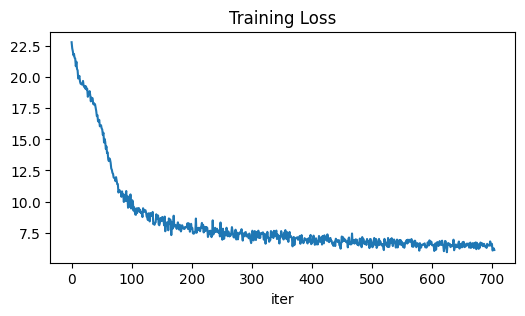

Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 30.17it/s]

Total test samples: 10000
Overall accuracy: 94.01%
Classifier accuracy (on 8524 non-deferred): 99.30%
Classifier accuracy (if predicted all): 97.38%
Expert accuracy (on 1476 deferred): 63.48%
Deferral rate: 14.76%

Expert abilities (psi):
tensor([[1.0000, 0.0823, 0.0949, 1.0000, 0.1019, 1.0000, 1.0000, 1.0000, 0.1140,
         0.0843]])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertEmbeddingEncoder, ExpertDecisionModule

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 6
phi_dim = 8
feature_dim = 128
epochs = 3
lr = 1e-4
seed = 0

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

expert_pop = PopulationSimulator(num_experts=num_experts,
                                 num_classes=num_classes,
                                 overlap_prob=0.1,
                                 oracle_classes_per_expert=5)

# models
cnn = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
encoder = ExpertEmbeddingEncoder(num_classes=num_classes, phi_dim=phi_dim, hidden=[64,32]).to(device)
l2d = ExpertDecisionModule(feature_dim=feature_dim, num_classes=num_classes,
               phi_dim=phi_dim, num_experts=num_experts,
               classifier_hidden=[256], rejector_hidden=[128]).to(device)

loss_function = L2D_Equation7_Loss(num_classes=num_classes, num_experts=num_experts)
optimizer = optim.Adam(list(cnn.parameters()) + list(encoder.parameters()) + list(l2d.parameters()),
                       lr=lr, weight_decay=1e-4)

loss_history = []
psi = expert_pop.sample_expert_probabilities()  # [E, K]
for epoch in range(epochs):
    cnn.train()
    encoder.train()
    l2d.train()

    
    running = []
    pbar = tqdm(train_loader, desc=f"Train epoch {epoch+1}/{epochs}")

    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)  # [B,E]

        psi_tensor = psi.to(device) 
        phi_emb = encoder(psi_tensor)                     # [E, phi_dim]
        f_x = cnn(imgs)
        g_classes, g_perp = l2d(f_x, phi_emb)

        loss = loss_function.forward(g_classes, g_perp, labels, expert_preds)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running.append(loss.item())
        loss_history.append(loss.item())
        pbar.set_postfix({'loss': f"{np.mean(running):.4f}"})

    print(f"Epoch {epoch+1} mean loss: {np.mean(running):.4f}")

# loss plot
plt.figure(figsize=(6,3))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("iter")
plt.show()

evaluator = L2D_Eval_Population(cnn, encoder, l2d, expert_pop, num_classes, device)
metrics = evaluator.evaluate_single_expert(test_loader, expert_idx=0)
evaluator.print_results(metrics)


=== Overlap 0.1 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 33.45it/s]



=== Overlap 0.2 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 33.19it/s]



=== Overlap 0.4 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 34.43it/s]



=== Overlap 0.8 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 35.44it/s]



=== Overlap 0.999 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 36.43it/s]


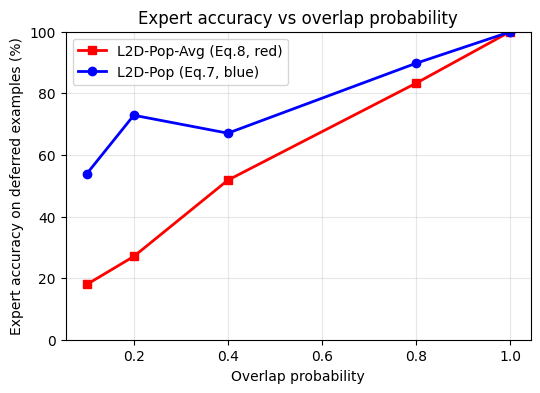

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertEmbeddingEncoder, ExpertDecisionModule

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 10
lr = 1e-4
seed = 10
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.1, 0.2, 0.4, 0.8, 0.999]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in overlaps:
    print(f"\n=== Overlap {overlap} ===")
    # Create expert population
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # --- BLUE LINE: Eq. 7  ---
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    encoder_blue = ExpertEmbeddingEncoder(num_classes=num_classes, phi_dim=phi_dim, hidden=[64,32]).to(device)
    l2d_blue = ExpertDecisionModule(feature_dim=feature_dim, num_classes=num_classes,
               phi_dim=phi_dim, num_experts=num_experts,
               classifier_hidden=[256], rejector_hidden=[128]).to(device)
    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(list(cnn_blue.parameters()) + list(encoder_blue.parameters()) + list(l2d_blue.parameters()),
                           lr=lr, weight_decay=1e-4)

    psi = expert_pop.sample_expert_probabilities()
    for epoch in range(epochs):
        cnn_blue.train(); encoder_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)
            psi_tensor = psi.to(device)
            phi_emb = encoder_blue(psi_tensor)
            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, phi_emb)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)
            optimizer_blue.zero_grad(); loss.backward(); optimizer_blue.step()

    evaluator = L2D_Eval_Population(cnn_blue, encoder_blue, l2d_blue, expert_pop, num_classes, device)
    metrics_blue = evaluator.evaluate_single_expert(test_loader, expert_idx=0)
    acc_blue.append(metrics_blue["expert_accuracy"])

    # --- RED LINE: Eq. 8 (population-average) ---
    cnn_red = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    encoder_red = ExpertEmbeddingEncoder(num_classes=num_classes, phi_dim=phi_dim, hidden=[64,32]).to(device)
    l2d_red = ExpertDecisionModule(feature_dim=feature_dim, num_classes=num_classes,
                                phi_dim=phi_dim, num_experts=num_experts,
                                classifier_hidden=[256], rejector_hidden=[128]).to(device)

    loss_red = L2D_PopAvg_Loss(num_classes, num_experts)
    optimizer_red = optim.Adam(list(cnn_red.parameters()) +
                            list(encoder_red.parameters()) +
                            list(l2d_red.parameters()),
                            lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        cnn_red.train(); encoder_red.train(); l2d_red.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # same expert simulation as blue
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)
            psi_tensor = psi.to(device)
            phi_emb = encoder_red(psi_tensor)
            f_x = cnn_red(imgs)
            g_classes, g_perp = l2d_red(f_x, phi_emb)

            loss = loss_red.forward(g_classes, g_perp, labels, expert_preds)

            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()

    evaluator_red = L2D_Eval_Population(cnn_red, encoder_red, l2d_red, expert_pop, num_classes, device)
    metrics_red = evaluator_red.evaluate_single_expert(test_loader, expert_idx=0)
    acc_popavg.append(metrics_red["expert_accuracy"])


plt.figure(figsize=(6,4))
plt.plot(overlaps, acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot(overlaps, acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()


In [20]:
print(acc_blue)

[16.0, 20.496894409937887, 38.421052631578945, 80.85513720485004, 99.87143224479301]


In [21]:
print(acc_popavg)

[17.94871794871795, 27.049180327868854, 51.8018018018018, 83.26241134751773, 99.91582491582491]



=== Overlap 0.1 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 30.69it/s]


Epoch 1, L2D-Pop-Avg loss = 1.1789
Epoch 2, L2D-Pop-Avg loss = 0.7071
Epoch 3, L2D-Pop-Avg loss = 0.6437
Epoch 4, L2D-Pop-Avg loss = 0.6142
Epoch 5, L2D-Pop-Avg loss = 0.6006
Epoch 6, L2D-Pop-Avg loss = 0.5889
Epoch 7, L2D-Pop-Avg loss = 0.5830
Epoch 8, L2D-Pop-Avg loss = 0.5767
Epoch 9, L2D-Pop-Avg loss = 0.5715
Epoch 10, L2D-Pop-Avg loss = 0.5676


Eval (expert 0): 100%|██████████| 20/20 [00:01<00:00, 15.53it/s]



=== Overlap 0.2 ===


...

Eval (expert 0): 100%|██████████| 20/20 [00:01<00:00, 17.41it/s]



=== Overlap 0.999 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 35.02it/s]


Epoch 1, L2D-Pop-Avg loss = 2.3998
Epoch 2, L2D-Pop-Avg loss = 1.6482
Epoch 3, L2D-Pop-Avg loss = 1.5537
Epoch 4, L2D-Pop-Avg loss = 1.5137
Epoch 5, L2D-Pop-Avg loss = 1.4914
Epoch 6, L2D-Pop-Avg loss = 1.4750
Epoch 7, L2D-Pop-Avg loss = 1.4644
Epoch 8, L2D-Pop-Avg loss = 1.4558
Epoch 9, L2D-Pop-Avg loss = 1.4501
Epoch 10, L2D-Pop-Avg loss = 1.4448


Eval (expert 0): 100%|██████████| 20/20 [00:01<00:00, 18.39it/s]


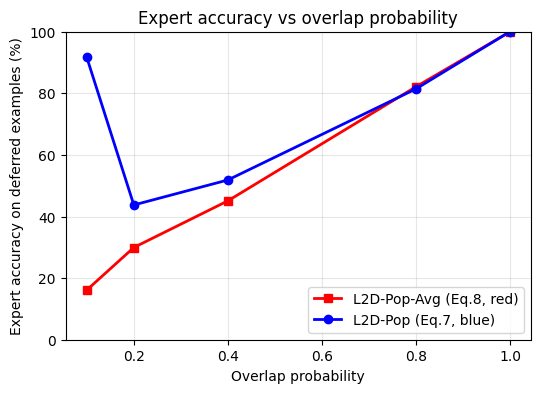

[91.66666666666667, 43.75, 51.86440677966102, 81.43491124260355, 99.95113608600049]
[16.129032258064516, 29.940119760479043, 45.08816120906801, 82.13507625272331, 99.89767203888462]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertEmbeddingEncoder, ExpertDecisionModule, ExpertDecisionModuleAvg

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 10
lr = 1e-4
seed = 10
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.1, 0.2, 0.4, 0.8, 0.999]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in overlaps:
    print(f"\n=== Overlap {overlap} ===")
    # Create expert population
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # --- BLUE LINE: Eq. 7  ---
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    encoder_blue = ExpertEmbeddingEncoder(num_classes=num_classes, phi_dim=phi_dim, hidden=[64,32]).to(device)
    l2d_blue = ExpertDecisionModule(feature_dim=feature_dim, num_classes=num_classes,
               phi_dim=phi_dim, num_experts=num_experts,
               classifier_hidden=[256], rejector_hidden=[128]).to(device)
    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(list(cnn_blue.parameters()) + list(encoder_blue.parameters()) + list(l2d_blue.parameters()),
                           lr=lr, weight_decay=1e-4)

    psi = expert_pop.sample_expert_probabilities()
    for epoch in range(epochs):
        cnn_blue.train(); encoder_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)
            psi_tensor = psi.to(device)
            phi_emb = encoder_blue(psi_tensor)
            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, phi_emb)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)
            optimizer_blue.zero_grad(); loss.backward(); optimizer_blue.step()

    evaluator = L2D_Eval_Population(cnn_blue, encoder_blue, l2d_blue, expert_pop, num_classes, device)
    metrics_blue = evaluator.evaluate_single_expert(test_loader, expert_idx=0)
    acc_blue.append(metrics_blue["expert_accuracy"])

    # --- RED LINE: Eq. 8 (population-average) ---
    model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
    loss_red = L2D_PopAvg_Loss(num_classes)
    optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

    # Training loop
    for epoch in range(epochs):
        model_red.train()
        running = []
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            g_classes, g_perp = model_red(imgs)
            loss = loss_red(g_classes, g_perp, labels, expert_preds)

            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()
            running.append(loss.item())


    # Evaluation
    cnn_eval = model_red.feature_extractor
    l2d_eval = model_red
    encoder_red = None

    evaluator_red = L2D_Eval_Population(cnn_eval, encoder_red, l2d_eval, expert_pop, num_classes, device)
    metrics_red = evaluator_red.evaluate_single_expert(test_loader, expert_idx=0)
    acc_popavg.append(metrics_red["expert_accuracy"])

plt.figure(figsize=(6,4))
plt.plot(overlaps, acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot(overlaps, acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()

print(acc_blue)
print(acc_popavg)


=== Overlap 0.1 ===


Eval (expert 0): 100%|██████████| 20/20 [00:01<00:00, 17.52it/s]



=== Overlap 0.2 ===


Eval (expert 0): 100%|██████████| 20/20 [00:01<00:00, 17.80it/s]



=== Overlap 0.4 ===


Eval (expert 0): 100%|██████████| 20/20 [00:01<00:00, 16.94it/s]



=== Overlap 0.8 ===


Eval (expert 0): 100%|██████████| 20/20 [00:01<00:00, 17.94it/s]



=== Overlap 0.999 ===


Eval (expert 0): 100%|██████████| 20/20 [00:01<00:00, 18.30it/s]


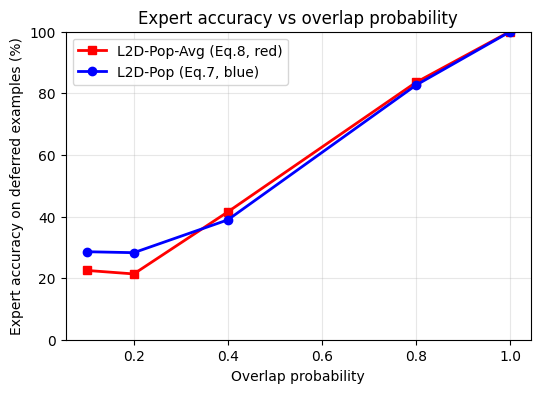

[28.571428571428573, 28.26086956521739, 38.92617449664429, 82.64182895850973, 99.90096558554097]
[22.5, 21.359223300970875, 41.515151515151516, 83.54500276090558, 100.0]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertEmbeddingEncoder, ExpertDecisionModule, ExpertDecisionModuleAvg

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 10
lr = 1e-4
seed = 10
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.1, 0.2, 0.4, 0.8, 0.999]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in overlaps:
    print(f"\n=== Overlap {overlap} ===")
    # Create expert population
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # --- BLUE LINE: Eq. 7  ---
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    encoder_blue = ExpertEmbeddingEncoder(num_classes=num_classes, phi_dim=phi_dim, hidden=[64,32]).to(device)
    l2d_blue = ExpertDecisionModule(feature_dim=feature_dim, num_classes=num_classes,
               phi_dim=phi_dim, num_experts=num_experts,
               classifier_hidden=[256], rejector_hidden=[128]).to(device)
    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(list(cnn_blue.parameters()) + list(encoder_blue.parameters()) + list(l2d_blue.parameters()),
                           lr=lr, weight_decay=1e-4)

    psi = expert_pop.sample_expert_probabilities()
    for epoch in range(epochs):
        cnn_blue.train(); encoder_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)
            psi_tensor = psi.to(device)
            phi_emb = encoder_blue(psi_tensor)
            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, phi_emb)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)
            optimizer_blue.zero_grad(); loss.backward(); optimizer_blue.step()

    evaluator = L2D_Eval_Population(cnn_blue, encoder_blue, l2d_blue, expert_pop, num_classes, device)
    metrics_blue = evaluator.evaluate_single_expert(test_loader, expert_idx=0)
    acc_blue.append(metrics_blue["expert_accuracy"])

    # --- RED LINE: Eq. 8 (population-average) ---
    model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
    loss_red = L2D_PopAvg_Loss(num_classes)
    optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

    # Training loop
    for epoch in range(epochs):
        model_red.train()
        running = []
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            g_classes, g_perp = model_red(imgs)
            loss = loss_red(g_classes, g_perp, labels, expert_preds)

            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()
            running.append(loss.item())


    # Evaluation
    cnn_eval = model_red.feature_extractor
    l2d_eval = model_red
    encoder_red = None

    evaluator_red = L2D_Eval_Population(cnn_eval, encoder_red, l2d_eval, expert_pop, num_classes, device)
    metrics_red = evaluator_red.evaluate_single_expert(test_loader, expert_idx=0)
    acc_popavg.append(metrics_red["expert_accuracy"])

plt.figure(figsize=(6,4))
plt.plot(overlaps, acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot(overlaps, acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()

print(acc_blue)
print(acc_popavg)


=== Overlap 0.1 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 33.03it/s]



=== Overlap 0.2 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 33.01it/s]



=== Overlap 0.4 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 33.74it/s]



=== Overlap 0.8 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 35.50it/s]



=== Overlap 0.999 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 34.24it/s]


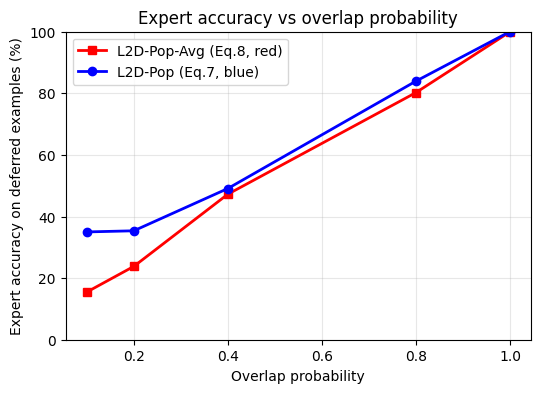

BLUE (Eq.7): [35.0, 35.36585365853659, 49.09747292418773, 83.95390070921985, 99.96299037749814]
RED (Eq.8): [15.476190476190476, 23.80952380952381, 47.252747252747255, 80.23774145616642, 99.87760097919217]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertDecisionModule, ExpertDecisionModuleAvg

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 10
lr = 1e-4
seed = 10
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.1, 0.2, 0.4, 0.8, 0.999]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in [0.1, 0.2, 0.4, 0.8, 0.999]:
    print(f"\n=== Overlap {overlap} ===")
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # Eq.7 — BLUE: Expert-Aware
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    l2d_blue = ExpertDecisionModule(
        feature_dim=feature_dim,
        num_classes=num_classes,
        phi_dim=num_classes,  # since phi has size [E, num_classes]
        num_experts=num_experts,
        classifier_hidden=[256],
        rejector_hidden=[128]
    ).to(device)

    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(
        list(cnn_blue.parameters()) + list(l2d_blue.parameters()),
        lr=lr, weight_decay=1e-4
    )

    psi = expert_pop.sample_expert_probabilities().to(device)

    for epoch in range(epochs):
        cnn_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, psi)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)

            optimizer_blue.zero_grad()
            loss.backward()
            optimizer_blue.step()

    evaluator_blue = L2D_Eval_Population(cnn_blue, l2d_blue, expert_pop, num_classes, device, expert_aware=True)
    metrics_blue = evaluator_blue.evaluate_single_expert(test_loader, expert_idx=0)
    acc_blue.append(metrics_blue["expert_accuracy"])

    # Eq.8 — RED: Population-Averaged
    model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
    loss_red = L2D_PopAvg_Loss(num_classes)
    optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        model_red.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            # Pass images directly - model has its own feature extractor
            g_classes, g_perp = model_red(imgs)
            loss = loss_red(g_classes, g_perp, labels, expert_preds)

            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()

    # Evaluator for RED - no separate CNN
    evaluator_red = L2D_Eval_Population(None, model_red, expert_pop, num_classes, device, expert_aware=False)
    metrics_red = evaluator_red.evaluate_single_expert(test_loader, expert_idx=0)
    acc_popavg.append(metrics_red["expert_accuracy"])
    
plt.figure(figsize=(6,4))
plt.plot([0.1, 0.2, 0.4, 0.8, 0.999], acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot([0.1, 0.2, 0.4, 0.8, 0.999], acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()

print("BLUE (Eq.7):", acc_blue)
print("RED (Eq.8):", acc_popavg)



=== Overlap 0.1 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 30.69it/s]



=== Overlap 0.2 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 32.33it/s]



=== Overlap 0.4 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 33.92it/s]



=== Overlap 0.8 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 34.83it/s]



=== Overlap 0.999 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 31.30it/s]


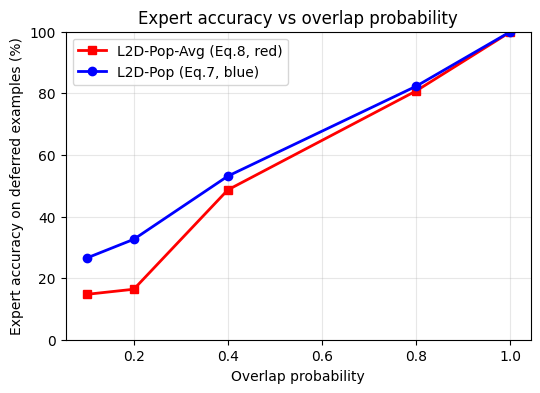

BLUE (Eq.7): [26.53061224489796, 32.608695652173914, 53.125, 82.27091633466135, 99.84942593638246]
RED (Eq.8): [14.736842105263158, 16.39344262295082, 48.655913978494624, 80.74369189907038, 99.75837072833966]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertDecisionModule, ExpertDecisionModuleAvg

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 10
lr = 1e-4
seed = 10
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.1, 0.2, 0.4, 0.8, 0.999]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in [0.1, 0.2, 0.4, 0.8, 0.999]:
    print(f"\n=== Overlap {overlap} ===")
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # Eq.7 — BLUE: Expert-Aware
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    l2d_blue = ExpertDecisionModule(
        feature_dim=feature_dim,
        num_classes=num_classes,
        phi_dim=num_classes,  # since phi has size [E, num_classes]
        num_experts=num_experts,
        classifier_hidden=[256],
        rejector_hidden=[128]
    ).to(device)

    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(
        list(cnn_blue.parameters()) + list(l2d_blue.parameters()),
        lr=lr, weight_decay=1e-4
    )

    psi = expert_pop.sample_expert_probabilities().to(device)

    for epoch in range(epochs):
        cnn_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, psi)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)

            optimizer_blue.zero_grad()
            loss.backward()
            optimizer_blue.step()

    evaluator_blue = L2D_Eval_Population(cnn_blue, l2d_blue, expert_pop, num_classes, device, expert_aware=True)
    metrics_blue = evaluator_blue.evaluate_single_expert(test_loader, expert_idx=0)
    acc_blue.append(metrics_blue["expert_accuracy"])

    # Eq.8 — RED: Population-Averaged
    model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
    loss_red = L2D_PopAvg_Loss(num_classes)
    optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        model_red.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            # Pass images directly - model has its own feature extractor
            g_classes, g_perp = model_red(imgs)
            loss = loss_red(g_classes, g_perp, labels, expert_preds)

            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()

    # Evaluator for RED - no separate CNN
    evaluator_red = L2D_Eval_Population(None, model_red, expert_pop, num_classes, device, expert_aware=False)
    metrics_red = evaluator_red.evaluate_single_expert(test_loader, expert_idx=0)
    acc_popavg.append(metrics_red["expert_accuracy"])
    
plt.figure(figsize=(6,4))
plt.plot([0.1, 0.2, 0.4, 0.8, 0.999], acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot([0.1, 0.2, 0.4, 0.8, 0.999], acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()

print("BLUE (Eq.7):", acc_blue)
print("RED (Eq.8):", acc_popavg)



=== Overlap 0.1 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 32.92it/s]



=== Overlap 0.2 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 31.55it/s]



=== Overlap 0.4 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 33.27it/s]



=== Overlap 0.8 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 35.15it/s]



=== Overlap 0.999 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 35.02it/s]


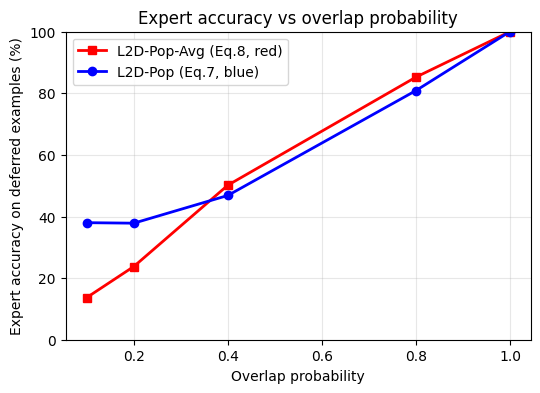

BLUE (Eq.7): [38.0, 37.83783783783784, 46.8421052631579, 80.89500860585198, 99.95978282726725]
RED (Eq.8): [13.698630136986301, 23.770491803278688, 50.174216027874564, 85.26315789473684, 99.96709985194933]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertDecisionModule, ExpertDecisionModuleAvg

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 15
lr = 1e-4
seed = 7
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.1, 0.2, 0.4, 0.8, 0.999]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in [0.1, 0.2, 0.4, 0.8, 0.999]:
    print(f"\n=== Overlap {overlap} ===")
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # Eq.7 — BLUE: Expert-Aware
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    l2d_blue = ExpertDecisionModule(
        feature_dim=feature_dim,
        num_classes=num_classes,
        phi_dim=num_classes,  # since phi has size [E, num_classes]
        num_experts=num_experts,
        classifier_hidden=[256],
        rejector_hidden=[128]
    ).to(device)

    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(
        list(cnn_blue.parameters()) + list(l2d_blue.parameters()),
        lr=lr, weight_decay=1e-4
    )

    psi = expert_pop.sample_expert_probabilities().to(device)

    for epoch in range(epochs):
        cnn_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, psi)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)

            optimizer_blue.zero_grad()
            loss.backward()
            optimizer_blue.step()

    evaluator_blue = L2D_Eval_Population(cnn_blue, l2d_blue, expert_pop, num_classes, device, expert_aware=True)
    metrics_blue = evaluator_blue.evaluate_single_expert(test_loader, expert_idx=0)
    acc_blue.append(metrics_blue["expert_accuracy"])

    # Eq.8 — RED: Population-Averaged
    model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
    loss_red = L2D_PopAvg_Loss(num_classes)
    optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        model_red.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            # Pass images directly - model has its own feature extractor
            g_classes, g_perp = model_red(imgs)
            loss = loss_red(g_classes, g_perp, labels, expert_preds)

            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()

    # Evaluator for RED - no separate CNN
    evaluator_red = L2D_Eval_Population(None, model_red, expert_pop, num_classes, device, expert_aware=False)
    metrics_red = evaluator_red.evaluate_single_expert(test_loader, expert_idx=0)
    acc_popavg.append(metrics_red["expert_accuracy"])
    
plt.figure(figsize=(6,4))
plt.plot([0.1, 0.2, 0.4, 0.8, 0.999], acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot([0.1, 0.2, 0.4, 0.8, 0.999], acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()

print("BLUE (Eq.7):", acc_blue)
print("RED (Eq.8):", acc_popavg)



=== Overlap 0.1 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 34.03it/s]



=== Overlap 0.2 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 34.48it/s]



=== Overlap 0.4 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 34.91it/s]



=== Overlap 0.8 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 35.60it/s]



=== Overlap 0.999 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 35.99it/s]


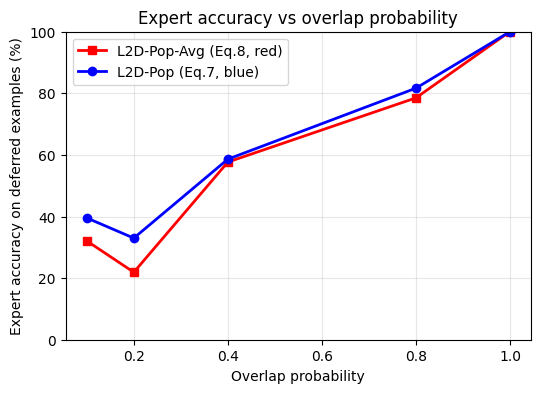

BLUE (Eq.7): [39.53488372093023, 32.98969072164948, 58.62068965517241, 81.6711590296496, 99.92482616049615]
RED (Eq.8): [32.075471698113205, 21.904761904761905, 57.67790262172284, 78.52348993288591, 99.97081995914795]


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertDecisionModule, ExpertDecisionModuleAvg

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 15
lr = 1e-4
seed = 10
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.1, 0.2, 0.4, 0.8, 0.999]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in [0.1, 0.2, 0.4, 0.8, 0.999]:
    print(f"\n=== Overlap {overlap} ===")
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # Eq.7 — BLUE: Expert-Aware
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    l2d_blue = ExpertDecisionModule(
        feature_dim=feature_dim,
        num_classes=num_classes,
        phi_dim=num_classes,  # since phi has size [E, num_classes]
        num_experts=num_experts,
        classifier_hidden=[256],
        rejector_hidden=[128]
    ).to(device)

    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(
        list(cnn_blue.parameters()) + list(l2d_blue.parameters()),
        lr=lr, weight_decay=1e-4
    )

    psi = expert_pop.sample_expert_probabilities().to(device)

    for epoch in range(epochs):
        cnn_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, psi)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)

            optimizer_blue.zero_grad()
            loss.backward()
            optimizer_blue.step()

    evaluator_blue = L2D_Eval_Population(cnn_blue, l2d_blue, expert_pop, num_classes, device, expert_aware=True)
    metrics_blue = evaluator_blue.evaluate_single_expert(test_loader, expert_idx=0)
    acc_blue.append(metrics_blue["expert_accuracy"])

    # Eq.8 — RED: Population-Averaged
    model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
    loss_red = L2D_PopAvg_Loss(num_classes)
    optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        model_red.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            # Pass images directly - model has its own feature extractor
            g_classes, g_perp = model_red(imgs)
            loss = loss_red(g_classes, g_perp, labels, expert_preds)

            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()

    # Evaluator for RED - no separate CNN
    evaluator_red = L2D_Eval_Population(None, model_red, expert_pop, num_classes, device, expert_aware=False)
    metrics_red = evaluator_red.evaluate_single_expert(test_loader, expert_idx=0)
    acc_popavg.append(metrics_red["expert_accuracy"])
    
plt.figure(figsize=(6,4))
plt.plot([0.1, 0.2, 0.4, 0.8, 0.999], acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot([0.1, 0.2, 0.4, 0.8, 0.999], acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()

print("BLUE (Eq.7):", acc_blue)
print("RED (Eq.8):", acc_popavg)



=== Overlap 0.001 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 32.21it/s]



=== Overlap 0.1 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 29.97it/s]



=== Overlap 0.2 ===


...

Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 32.76it/s]



=== Overlap 0.8 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 34.44it/s]



=== Overlap 0.999 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 35.80it/s]


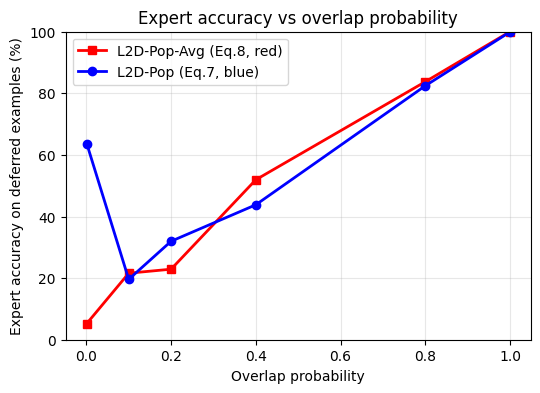

BLUE (Eq.7): [63.63636363636363, 19.607843137254903, 31.9672131147541, 43.80530973451327, 82.43080625752106, 99.83810037776578]
RED (Eq.8): [5.2631578947368425, 21.6, 22.900763358778626, 51.92982456140351, 83.75378405650858, 99.94563247553461]


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertDecisionModule, ExpertDecisionModuleAvg

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.l2d_eval_from_pop import L2D_Eval_Population

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 10
lr = 1e-4
seed = 10
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.001, 0.1, 0.2, 0.4, 0.8, 0.999]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in overlaps:
    print(f"\n=== Overlap {overlap} ===")
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # Eq.7 — BLUE: Expert-Aware
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    l2d_blue = ExpertDecisionModule(
        feature_dim=feature_dim,
        num_classes=num_classes,
        phi_dim=num_classes,  # since phi has size [E, num_classes]
        num_experts=num_experts,
        classifier_hidden=[256],
        rejector_hidden=[128]
    ).to(device)

    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(
        list(cnn_blue.parameters()) + list(l2d_blue.parameters()),
        lr=lr, weight_decay=1e-4
    )

    psi = expert_pop.sample_expert_probabilities().to(device)

    for epoch in range(epochs):
        cnn_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, psi)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)

            optimizer_blue.zero_grad()
            loss.backward()
            optimizer_blue.step()

    evaluator_blue = L2D_Eval_Population(cnn_blue, l2d_blue, expert_pop, num_classes, device, expert_aware=True)
    metrics_blue = evaluator_blue.evaluate_single_expert(test_loader, expert_idx=0)
    acc_blue.append(metrics_blue["expert_accuracy"])

    # Eq.8 — RED: Population-Averaged
    model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
    loss_red = L2D_PopAvg_Loss(num_classes)
    optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        model_red.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)

            # Pass images directly - model has its own feature extractor
            g_classes, g_perp = model_red(imgs)
            loss = loss_red(g_classes, g_perp, labels, expert_preds)

            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()

    # Evaluator for RED - no separate CNN
    evaluator_red = L2D_Eval_Population(None, model_red, expert_pop, num_classes, device, expert_aware=False)
    metrics_red = evaluator_red.evaluate_single_expert(test_loader, expert_idx=0)
    acc_popavg.append(metrics_red["expert_accuracy"])
    
plt.figure(figsize=(6,4))
plt.plot([0.001, 0.1, 0.2, 0.4, 0.8, 0.999], acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot([0.001, 0.1, 0.2, 0.4, 0.8, 0.999], acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()

print("BLUE (Eq.7):", acc_blue)
print("RED (Eq.8):", acc_popavg)
